In [38]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import IsolationForest
import koreanize_matplotlib

# 1. Jupyter Notebook 위치(experiments 폴더) 기준 절대 경로 설정
BASE_DIR = os.getcwd()  # 현재 experiments 디렉토리 경로
PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, '..'))  # 프로젝트 최상위 루트 경로
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')  # data/processed 절대 경로
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')  # reports/figures 절대 경로

# 2. 프로젝트 루트를 sys.path에 추가하여 src 패키지 인식
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 3. src.utils 모듈에서 Autoencoder 클래스 및 evaluate_thresholds 함수 불러오기
from src.utils import Autoencoder, evaluate_thresholds

In [39]:
# 전용 시각화 및 reports/figures 저장 함수 정의
"""
    df_results: evaluate_thresholds 결과 데이터프레임
    model_name: 그래프 제목에 표시할 모델 이름 (예: 'Isolation Forest')
    filename: reports/figures 폴더에 저장할 파일명 (예: 'isolation_forest_simulation.png')
"""
def plot_and_save_simulation(df_results, model_name, filename):
    os.makedirs(FIGURES_DIR, exist_ok=True) # reports/figures 폴더가 없으면 새로 생성
    save_path = os.path.join(FIGURES_DIR, filename) #최종 저장할 파일의 경로

    fig, ax1 = plt.subplots(figsize=(10,6)) #가로 세로 6인치 크기의 그래프 도화지

    # 왼쪽 y축 : Recall 재현율 , Precision 정밀도
    # X축 라벨 설정
    ax1.set_xlabel('Threshold 이상치 점수 임계값', fontsize=12)
    # 왼쪽 Y축 라벨 설정
    ax1.set_ylabel('Score (Recall / Precision)', color='tab:blue', fontsize=12)
    # # Recall 선 그래프
    line1 = ax1.plot(df_results['Threshold'], df_results['Recall'], marker='o', color='tab:blue', label='Recall (사기 탐지율)')
    # Precision 선 그래프
    line2 = ax1.plot(df_results['Threshold'], df_results['Precision'], marker='s', color='tab:green', label='Precision (정밀도)')

    ax1.grid(True, linestyle='--', alpha=0.5)  # 점선 형태의 격자 배경 표시

    # 오른쪽 Y축: FP (상담원 검토 건수)
    ax2 = ax1.twinx()  # X축을 공유하는 오른쪽 Y축 생성
    ax2.set_ylabel('FP (오탐/검토 건수)', color='tab:red', fontsize=12)  # 오른쪽 Y축 라벨 설정
    line3 = ax2.plot(df_results['Threshold'], df_results['FP (오탐/검토 대상)'], marker='^', color='tab:red', linestyle='--', label='FP (검토 건수)')  # FP 선 그래프
    ax2.tick_params(axis='y', labelcolor='tab:red')  # 오른쪽 Y축 눈금 색상 변경

    # 범례(Legend) 및 타이틀 설정
    lines = line1 + line2 + line3  # 3개 그래프 선 정보 하나로 통합
    labels = [l.get_label() for l in lines]  # 범례 라벨 텍스트 추출
    ax1.legend(lines, labels, loc='center left')  # 중앙 왼쪽에 범례 상자 표시

    plt.title(f'[{model_name}] Threshold Simulation (Recall vs FP)', fontsize=14, pad=15)  # 그래프 제목 설정
    plt.tight_layout()  # 여백을 자동으로 깔끔하게 조정
    
    plt.savefig(save_path, dpi=300)  # 지정한 경로에 300 DPI 고해상도 이미지 파일로 저장
    plt.show()  # Jupyter Notebook 화면에 그래프 출력
    print(f"[저장 완료] 그래프 파일: {save_path}")  # 저장 완료 안내 출력

In [40]:
# 1. CSV 데이터 파일 로드
train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "train_processed.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "validation_processed.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "test_processed.csv"))

In [41]:
# 2. 독립변수(X)와 타겟 라벨(y) 분리
X_train = train_df.drop(columns=['Class']).values
y_train = train_df['Class'].values

X_val = val_df.drop(columns=['Class']).values
y_val = val_df['Class'].values

# 3. 오직 '정상 거래(Class 0)' 데이터만 추출
X_train_normal = X_train[y_train == 0]

print(f"정상 학습 데이터 크기: {X_train_normal.shape}")

정상 학습 데이터 크기: (198277, 30)


if_scores 고유값 개수: 42107
if_scores 최소/최대: 0.34865508097463055 0.7578798305599846
생성된 임계값 10개:
 [0.48526774 0.50732731 0.52938689 0.55144646 0.57350603 0.59556561
 0.61762518 0.63968475 0.66174433 0.6838039 ]


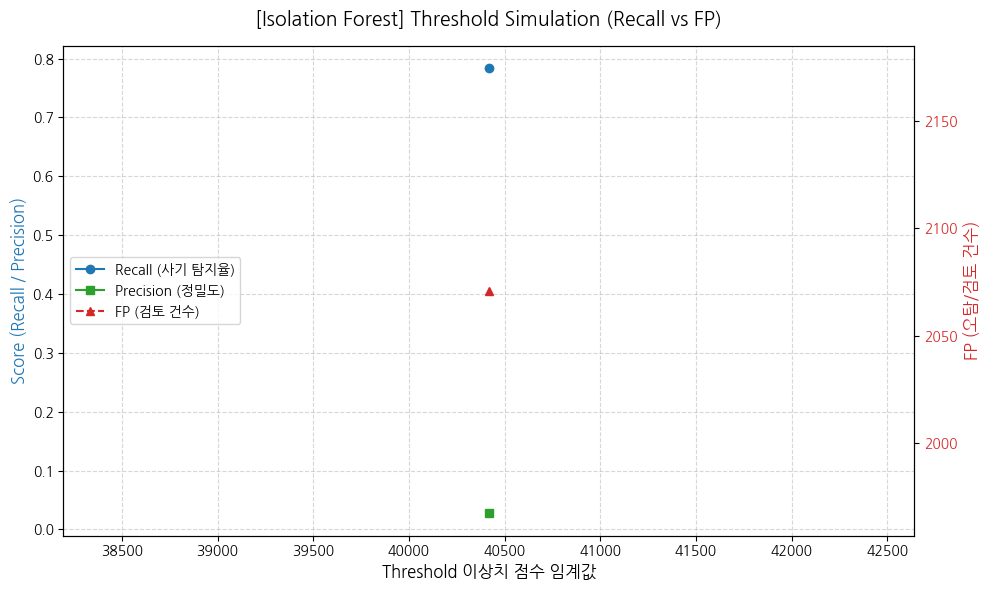

[저장 완료] 그래프 파일: /home/user1/study/credit-card-fds/reports/figures/isolation_forest_simulation.png


,Threshold,Recall,Precision,F1-Score,TP (사기 탐지),FP (오탐/검토 대상),FN (놓친 사기),Total Flagged (총 경고)
0,40417,0.783784,0.027243,0.052655,58,2071,16,2129


In [42]:
# 3. Isolation Forest 모델 학습, 시뮬레이션 및 그래프 저장
# (contamination: 데이터 내 예상 이상치 비율 0.17%)
iso_forest = IsolationForest(contamination=0.0017, random_state=42, n_jobs=-1)

# 정상거래 데이터만 가지고 Isolation Forest 패턴 학습
iso_forest.fit(X_train_normal)

# Validation 데이터의 이상치 점수 계산 (-를 붙여 점수가 높을수록 사기가 되도록 inverted)
if_scores = -iso_forest.score_samples(X_val)

# ls 에서 불러온 evaluate_thresholds 함수로 임계값별 Recall/FP 계산
df_if_results = evaluate_thresholds(y_val, if_scores)

# 점수 생성이 제대로 되었는지 확인
print("if_scores 고유값 개수:", len(np.unique(if_scores)))
print("if_scores 최소/최대:", if_scores.min(), if_scores.max())

# 임계값 10개 뽑아보기
th_test = np.linspace(np.percentile(if_scores, 95), np.percentile(if_scores, 99.9), 10)
print("생성된 임계값 10개:\n", th_test)

# 시각화 수행 및 reports/figures/isolation_forest_simulation.png 저장
plot_and_save_simulation(
    df_results=df_if_results, #계산된 평가 지표 데이터 프레임
    model_name="Isolation Forest", #그래프 제목
    filename="isolation_forest_simulation.png" #저장 파일 명
)

#시뮬레이션 결과 데이터 프레임 표 출력
display(df_if_results)